# COM 3303 – Artificial Intelligence
## Mini Project Phase 03 – Implementation 1
### Dog vs Cat Image Classification System
**Group: ClassiFive | Rajarata University of Sri Lanka**

## SECTION 1: Install & Import Libraries

In [5]:
# Install kaggle if needed
!pip install -q kaggle

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## SECTION 2: Download Dataset from Kaggle
Paste your Kaggle API token below (the one starting with `KGAT_...`).
You can find it on: kaggle.com → Profile → Settings → API

In [21]:
import os

# ──────────────────────────────────────────────────────────
# PASTE YOUR KAGGLE API TOKEN HERE (between the quotes)
KAGGLE_TOKEN = "KGAT_42eadd04c5f22a59a17666af2b7a82d5"
KAGGLE_USERNAME = "dilshanudesh"
# ──────────────────────────────────────────────────────────

# Set up kaggle.json using the token
import json
kaggle_creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_TOKEN}
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Download and extract the dataset
!pip install -q kaggle
!kaggle datasets download -d salader/dogsVScats
!unzip -q dogsVScats.zip -d dogs-vs-cats

print("Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/salader/dogsVScats
License(s): unknown
 98% 1.04G/1.06G [00:04<00:00, 220MB/s]
100% 1.06G/1.06G [00:04<00:00, 269MB/s]
Dataset downloaded and extracted!


## SECTION 3: Dataset Preparation & Verification

In [23]:
BASE_DIR  = "dogs-vs-cats"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")

IMG_SIZE    = (64, 64)   # Reduced from 256x256 → much faster
BATCH_SIZE  = 64         # Larger batch → fewer steps per epoch
EPOCHS      = 30

# Verify dataset
print("Dataset Structure:")
for split, path in [("Train", TRAIN_DIR), ("Test", TEST_DIR)]:
    for cls in ["cats", "dogs"]:
        count = len(os.listdir(os.path.join(path, cls)))
        print(f"  {split} | {cls}: {count} images")

Dataset Structure:
  Train | cats: 10000 images
  Train | dogs: 10000 images
  Test | cats: 2500 images
  Test | dogs: 2500 images


## SECTION 4: Image Preprocessing
- Resize to 256×256
- Normalize pixels to [0, 1]
- Split: 80% train / 20% validation

In [24]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)
print(f"Training samples  : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples      : {test_generator.samples}")

Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.

Class indices: {'cats': 0, 'dogs': 1}
Training samples  : 16000
Validation samples: 4000
Test samples      : 5000


## SECTION 5: Visualize Sample Images

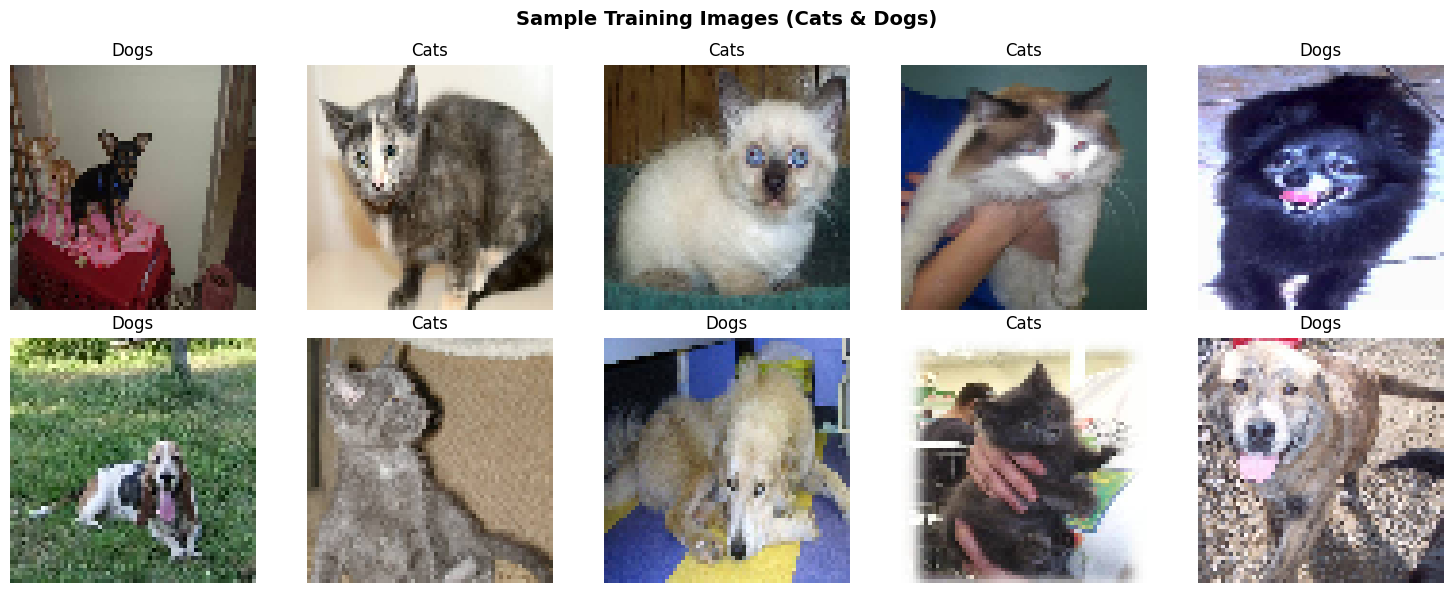

In [25]:
def show_samples(generator, title="Sample Images"):
    images, labels = next(generator)
    class_names = {v: k for k, v in generator.class_indices.items()}
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(title, fontsize=14, fontweight="bold")
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(class_names[int(labels[i])].capitalize())
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150)
    plt.show()

show_samples(train_generator, "Sample Training Images (Cats & Dogs)")

## SECTION 6: CNN Model Architecture
**Justification:** CNNs are used because they learn spatial hierarchies of features (edges → shapes → objects) through shared convolutional filters, making them the best choice for image classification tasks.

In [26]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),

        # Block 1: 32 filters
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 2: 64 filters
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 3: 128 filters
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Classification Head
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")  # Binary output
    ], name="DogCat_CNN_v1")

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model()
model.summary()

Model: "DogCat_CNN_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,191,809 (8.36 MB)

 Trainable params: 2,191,361 (8.36 MB)

 Non-trainable params: 448 (1.75 KB)

## SECTION 7: Model Training

In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint

model = build_model() # Initialize the model

checkpoint = ModelCheckpoint(
    "model_v1.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint],
    verbose=1
)

print("\nTraining complete. Best model saved as model_v1.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 968ms/step - accuracy: 0.6263 - loss: 0.9861
Epoch 1: val_accuracy improved from -inf to 0.50250, saving model to model_v1.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.6265 - loss: 0.9850 - val_accuracy: 0.5025 - val_loss: 1.3207
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 955ms/step - accuracy: 0.7518 - loss: 0.4973
Epoch 2: val_accuracy improved from 0.50250 to 0.57650, saving model to model_v1.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.7518 - loss: 0.4972 - val_accuracy: 0.5765 - val_loss: 0.7293
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 0.8044 - loss: 0.4277
Epoch 3: val_accuracy improved from 0.57650 to 0.62675, saving model to model_v1.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.8044 - loss: 0.4277 - val_accuracy: 0.6267 - val_loss: 0.8113
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.8423 - loss: 0.3565
Epoch 4: val_accuracy improved from 0.62675 to 0.75075, saving model to model_v1.h5


...

250/250 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.8954 - loss: 0.2493 - val_accuracy: 0.8255 - val_loss: 0.4043
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9146 - loss: 0.2049
Epoch 7: val_accuracy did not improve from 0.82550
250/250 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9146 - loss: 0.2049 - val_accuracy: 0.7673 - val_loss: 0.5950
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 954ms/step - accuracy: 0.9382 - loss: 0.1539
Epoch 8: val_accuracy improved from 0.82550 to 0.83000, saving model to model_v1.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.9381 - loss: 0.1539 - val_accuracy: 0.8300 - val_loss: 0.4834
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 984ms/step - accuracy: 0.9443 - loss: 0.1375
Epoch 9: val_accuracy improved from 0.83000 to 0.85400, saving model to model_v1.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9443 - loss: 0.1376 - val_accuracy: 0.8540 - val_loss: 0.4429
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.9630 - loss: 0.0977
Epoch 10: val_accuracy did not improve from 0.85400
250/250 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9630 - loss: 0.0977 - val_accuracy: 0.8410 - val_loss: 0.5493
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 966ms/step - accuracy: 0.9714 - loss: 0.0782
Epoch 11: val_accuracy did not improve from 0.85400
250/250 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9713 - loss: 0.0782 - val_accuracy: 0.7878 - val_loss: 0.6839
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.9669 - loss: 0.0845
Epoch 12: val_accuracy did not improve from 0.85400
250/250 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9669 - loss: 0.0845 - val_accuracy: 0.8300 - val_loss: 0.5518
Epoch 13/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.9738 - loss: 0.0688
Epoch 13: val_ac

250/250 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.9885 - loss: 0.0334 - val_accuracy: 0.8553 - val_loss: 0.6269
Epoch 28/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 966ms/step - accuracy: 0.9911 - loss: 0.0240
Epoch 28: val_accuracy did not improve from 0.85525
250/250 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9911 - loss: 0.0240 - val_accuracy: 0.8537 - val_loss: 0.7449
Epoch 29/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.9903 - loss: 0.0301
Epoch 29: val_accuracy improved from 0.85525 to 0.85775, saving model to model_v1.h5


250/250 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9903 - loss: 0.0301 - val_accuracy: 0.8577 - val_loss: 0.9033
Epoch 30/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 944ms/step - accuracy: 0.9884 - loss: 0.0319
Epoch 30: val_accuracy did not improve from 0.85775
250/250 ━━━━━━━━━━━━━━━━━━━━ 257s 1s/step - accuracy: 0.9884 - loss: 0.0319 - val_accuracy: 0.8388 - val_loss: 0.7320

Training complete. Best model saved as model_v1.h5


## SECTION 8: Plot Training & Validation Curves

In [ ]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history["accuracy"],     label="Train Accuracy",      color="steelblue")
    ax1.plot(history.history["val_accuracy"], label="Validation Accuracy",  color="tomato", linestyle="--")
    ax1.set_title("Training & Validation Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history["loss"],     label="Train Loss",      color="steelblue")
    ax2.plot(history.history["val_loss"], label="Validation Loss",  color="tomato", linestyle="--")
    ax2.set_title("Training & Validation Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Implementation 1 – Initial CNN Model", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

plot_history(history)

## SECTION 9: Model Evaluation on Test Set

In [ ]:
best_model = keras.models.load_model("model_v1.h5")

test_loss, test_acc = best_model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# Predictions
test_generator.reset()
preds       = best_model.predict(test_generator, verbose=1)
pred_labels = (preds > 0.5).astype(int).flatten()
true_labels = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix – Implementation 1")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

## SECTION 10: Sample Predictions

In [ ]:
def show_predictions(model, generator, n=10):
    generator.reset()
    images, true_labels = next(generator)
    preds = model.predict(images[:n], verbose=0)
    pred_labels = (preds > 0.5).astype(int).flatten()
    class_names = {v: k for k, v in generator.class_indices.items()}

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        true  = class_names[int(true_labels[i])].capitalize()
        pred  = class_names[pred_labels[i]].capitalize()
        conf  = preds[i][0] if pred_labels[i] == 1 else 1 - preds[i][0]
        color = "green" if true == pred else "red"
        ax.set_title(f"True: {true}\nPred: {pred} ({conf*100:.1f}%)", color=color, fontsize=9)
        ax.axis("off")
    plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("sample_predictions.png", dpi=150)
    plt.show()

show_predictions(best_model, test_generator)

## SECTION 11: Predict a Single Custom Image

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]
    label      = "Dog" if prediction > 0.5 else "Cat"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(f"Prediction: {label} ({confidence * 100:.2f}% confidence)")
    plt.imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    plt.title(f"Prediction: {label} ({confidence * 100:.2f}%)")
    plt.axis("off")
    plt.show()

# Usage: predict_image("your_image.jpg", best_model)

## SECTION 12: Save Model

In [ ]:
# Best model already saved as model_v1.h5 via checkpoint during training
# Save the final epoch model as well:
model.save("model_v1_final.h5")
print("model_v1.h5       → Best model (highest val_accuracy)")
print("model_v1_final.h5 → Final epoch model")

# Optional: Save to Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# !cp model_v1.h5 '/content/drive/MyDrive/model_v1.h5'